---
skip_execution: true
---

(falling_object_demo)=
# A. Falling object problem

This notebook demonstrates performing Bayesian inference with CUQIpy on a simple physical model of a falling object with air resistance. We will estimate the gravitational acceleration `g` and the air resistance coefficient `C` from noisy measurements of the object's fall distance over time. Our considered problem is a simplifed version of that described in @allmaras2013estimating.

This notebook focuses on implementation with all code organized in order. Only limited description of the problem is provided here and readers should refer to {ref}`section:computational-uq` in the main book for details, particularly on the influence of priors.

## 1. Import necessary packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cuqi

## 2. Define forward model and synthetic measurement

In [2]:
# Forward model
class FallingObject:
    def __init__(self, t, t0=0.0):
        self.t = np.asarray(t)
        self.t0 = t0

    def __call__(self, x):
        """Analytical solution for a body falling with quadratic air resistance."""
        g, C = x
        v_inf = np.sqrt(g / C)
        tau = self.t - self.t0
        z = (1.0 / C) * np.log(np.cosh(g * tau / v_inf))
        return z

# Parameters
g_true = 9.816 # m/s²  (true gravitational acceleration)
C_true = 0.1 # m⁻¹   (true air resistance coefficient)
t0     = 0.0 # s     (release time)
fps    = 30 # frames per second (as in the paper)

# Simulate ~30 frames after release
n_frames  = 30
frame_ids = np.arange(n_frames)
t_meas    = t0 + frame_ids / fps   # measurement times

# Clean (noise-free) fall distances
falling_object_meas = FallingObject(t_meas, t0)
z_clean = falling_object_meas([g_true, C_true])

noise_std = 0.1
np.random.seed(2026)  # for reproducibility
z_meas = z_clean + noise_std * np.random.randn(len(z_clean))  # Noisy measurements

# Dense trajectory for plotting
t_dense = np.linspace(0.0, t_meas[-1] + 0.05, 500)
falling_object_dense = FallingObject(t_dense, t0)
z_dense = falling_object_dense([g_true, C_true])

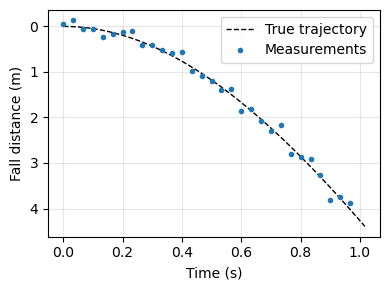

In [3]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(t_dense, z_dense, 'k--', linewidth=1.0, label='True trajectory')
ax.plot(t_meas, z_meas, 'o', linewidth=1.0, color='tab:blue', label='Measurements', markersize=3)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Fall distance (m)')
# ax.set_title(f'Measurement with g = {g_true} m/s², C = {C_true} m⁻¹')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("data.png", dpi=300, bbox_inches='tight')

## 3. Define priors

We have three alternatives here:

**1. Uniform Prior:**
$$p(\mathbf{x}) = \text{Uniform}(g, C \mid g \in [8, 12], \, C \in [0.01, 0.25])$$

**2. Truncated Normal Prior:**
$$p(\mathbf{x}) = \mathcal{N}_{\text{trunc}}\left(\boldsymbol{\mu}, \boldsymbol{\Sigma}, \, \mathbf{a}, \mathbf{b}\right)$$
where $\boldsymbol{\mu} = [11.0, 0.1]^T$, $\boldsymbol{\Sigma} = \text{diag}([0.2^2, 0.2^2])$, $\mathbf{a} = [8.0, 0.01]^T$, and $\mathbf{b} = [12.0, 0.25]^T$.

**3. Truncated Normal Prior:**
$$p(\mathbf{x}) = \mathcal{N}_{\text{trunc}}\left(\boldsymbol{\mu}, \boldsymbol{\Sigma}, \, \mathbf{a}, \mathbf{b}\right)$$
where $\boldsymbol{\mu} = [11.0, 0.1]^T$, $\boldsymbol{\Sigma} = \text{diag}([2^2, 2^2])$, $\mathbf{a} = [8.0, 0.01]^T$, and $\mathbf{b} = [12.0, 0.25]^T$.

In [4]:
# 1. Uniform prior
x = cuqi.distribution.Uniform(np.array([8.0, 0.01]), np.array([12.0, 0.25])) # g within [8, 12], C within [0.01, 0.25]
# 2. Truncated normal prior (mean way off the ground truth, but with a small std)
# x = cuqi.distribution.TruncatedNormal(mean=np.array([11.0, 0.2]), std=np.array([0.2, 0.2]), low=np.array([8.0, 0.01]), high=np.array([12.0, 0.25]))
# 3. Truncated normal prior (mean way off the ground truth, and with a large std)
# x = cuqi.distribution.TruncatedNormal(mean=np.array([11.0, 0.2]), std=np.array([2, 2]), low=np.array([8.0, 0.01]), high=np.array([12.0, 0.25]))

## 4. Define likelihood and posterior

In [5]:
A = cuqi.model.Model(falling_object_meas, domain_geometry=2, range_geometry=len(z_meas))

# test A operator
A(x.sample())

# set likelihood and posterior
y = cuqi.distribution.Gaussian(A(x), noise_std**2) # likelihood with Gaussian noise

joint = cuqi.distribution.JointDistribution(y, x)

posterior = joint(y=z_meas) # posterior distribution for given measurements

## 5. Sample from posterior

In [6]:
np.random.seed(1234)  # for reproducibility
sampler = cuqi.sampler.MH(posterior, initial_point=np.array([9.0, 0.1]), scale=0.05)
sampler.warmup(10000)
sampler.sample(20000)
samples = sampler.get_samples().burnthin(10000, 20)

Warmup:   0%|          | 0/10000 [00:00<?, ?it/s, acc rate: 21.05%] /var/folders/6l/nx63qk9s1l7gst1rbgdfb5vc0000gp/T/ipykernel_31607/3367461526.py:10: RuntimeWarning: invalid value encountered in sqrt
  v_inf = np.sqrt(g / C)
Sample: 100%|██████████| 20000/20000 [00:14<00:00, 1375.13it/s, acc rate: 23.73%]


array([[<Axes: title={'center': 'x0'}>, <Axes: title={'center': 'x0'}>],
       [<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x1'}>]],
      dtype=object)

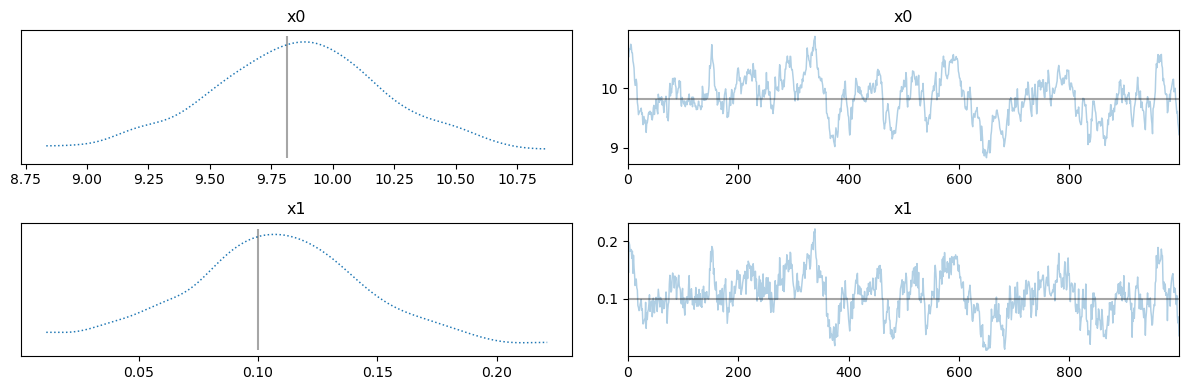

In [7]:
samples.plot_trace(exact=np.array([g_true, C_true]))

## 6. Compute MAP

In [8]:
from scipy.optimize import minimize, Bounds

# prepare bounds
low = np.asarray(getattr(x, 'low', [8.0, 0.01]), dtype=float).flatten()
high = np.asarray(getattr(x, 'high', [12.0, 0.25]), dtype=float).flatten()
bounds = Bounds(low, high)

def neg_logpost(theta):
    theta = np.asarray(theta, dtype=float)
    return -posterior.logpdf(theta)

# intial guess within bounds
x0 = np.array([10.0, 0.10])

minimize_kwargs = dict(
    fun=neg_logpost,
    x0=x0,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 1000, 'ftol': 1e-12, 'gtol': 1e-8},
)

res = minimize(**minimize_kwargs)

map_point = res.x
print("MAP estimate:", map_point)

MAP estimate: [9.86909618 0.10778037]


## 7. Plots of samples and density

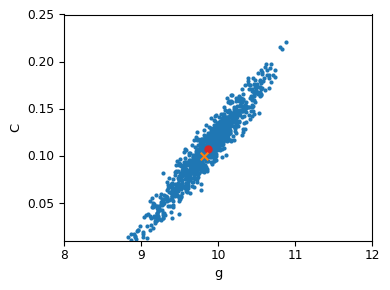

In [9]:
samples.plot_pair(figsize=(4, 3))
plt.scatter(map_point[0], map_point[1], s=100, c="tab:red", marker=".", label="MAP")
plt.scatter(g_true, C_true, s=30, c="tab:orange", marker="x", label="True value")
plt.gca().set_axisbelow(True)
# plt.grid(True, zorder=0)
plt.gca().set_xlabel("g")
plt.gca().set_ylabel("C")
plt.gca().set_xlim(8, 12)
plt.gca().set_ylim(0.01, 0.25)
plt.gca().set_xticks([8, 9, 10, 11, 12])
plt.tight_layout()
plt.savefig("samples.png", dpi=300, bbox_inches='tight')


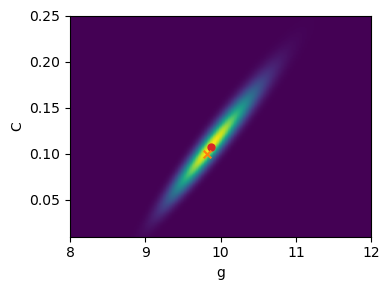

In [10]:
plt.figure(figsize=(4, 3))  # control figure size here
im = cuqi.utilities.plot_2D_density(
    posterior,
    v1_min=8.0, v1_max=12.0,
    v2_min=0.01, v2_max=0.25,
    N1=200, N2=200
)
plt.scatter(map_point[0], map_point[1], s=100, c="tab:red", marker=".", label="MAP")
plt.scatter(g_true, C_true, s=30, c="tab:orange", marker="x", label="True value")
# plt.grid()
plt.gca().set_aspect('auto')
plt.gca().set_xlabel("g")
plt.gca().set_ylabel("C")
plt.gca().set_xlim(8, 12)
plt.gca().set_ylim(0.01, 0.25)
# plt.colorbar(im)
plt.tight_layout()
plt.savefig("density.png", dpi=300, bbox_inches='tight')